In [26]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import random
import ntpath

from tensorflow.keras.callbacks import EarlyStopping
from imgaug import augmenters as iaa
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense,Lambda

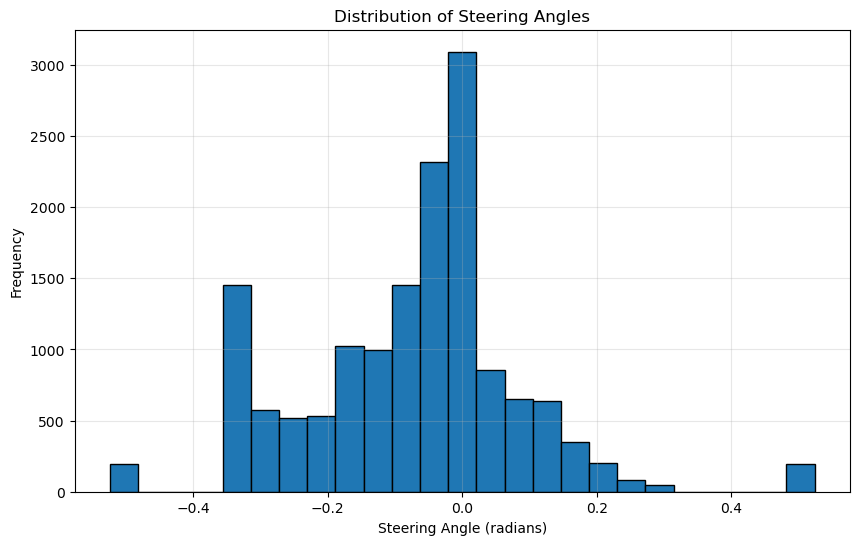

Steering Angle Statistics:
count    15181.000000
mean        -0.071322
std          0.158408
min         -0.523600
25%         -0.160200
50%         -0.044000
75%          0.007300
max          0.523600
Name: steering_angle, dtype: float64


In [16]:
# Load the CSV data
data = pd.read_csv('dataset/labels.csv')

# Ensure steering_angle is numeric and handle any potential issues
data['steering_angle'] = pd.to_numeric(data['steering_angle'], errors='coerce')
data = data.dropna(subset=['steering_angle'])  # Drop any NaN values
data['steering_angle'] = data['steering_angle'].astype(float)

# Create histogram
num_bins = 25
hist, bins = np.histogram(data['steering_angle'], bins=num_bins)
center = (bins[:-1] + bins[1:]) * 0.5

# Plot histogram
plt.figure(figsize=(10, 6))
plt.bar(center, hist, width=(bins[1] - bins[0]), edgecolor='black')
plt.xlabel('Steering Angle (radians)')
plt.ylabel('Frequency')
plt.title('Distribution of Steering Angles')
plt.grid(True, alpha=0.3)
plt.show()

# Optional: Print basic statistics to assess bias
print("Steering Angle Statistics:")
print(data['steering_angle'].describe())

Augmented dataset saved to labels_augmented.csv


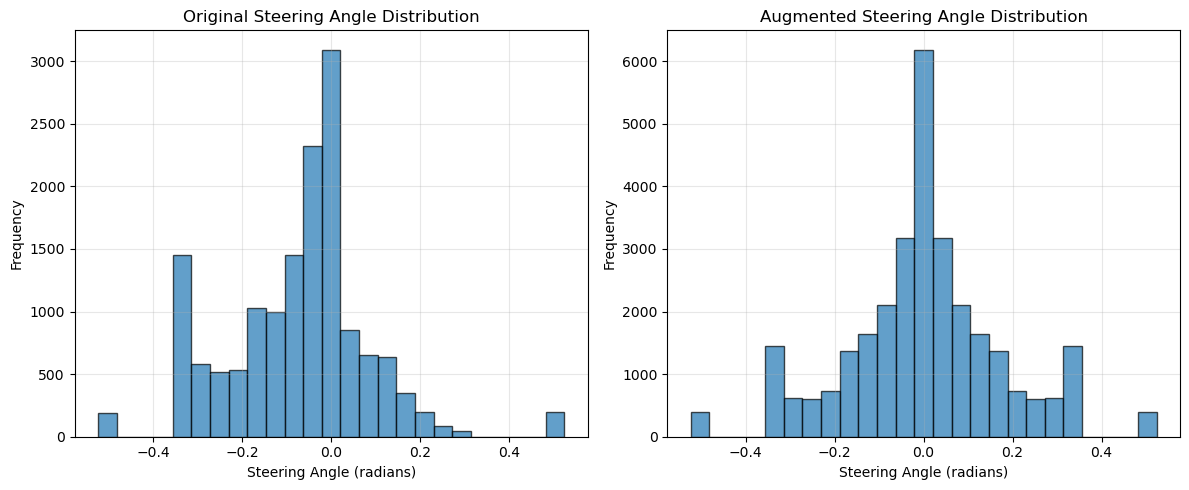


Original Steering Angle Statistics:
count    15181.000000
mean        -0.071322
std          0.158408
min         -0.523600
25%         -0.160200
50%         -0.044000
75%          0.007300
max          0.523600
Name: steering_angle, dtype: float64

Augmented Steering Angle Statistics:
count    30362.000000
mean         0.000000
std          0.173722
min         -0.523600
25%         -0.090600
50%          0.000000
75%          0.090600
max          0.523600
Name: steering_angle, dtype: float64


In [17]:
# Define paths
csv_path = 'dataset/labels.csv'  # Path to your CSV file
image_dir = 'dataset/images'     # Directory containing images (adjust as needed)
output_dir = 'images_mirrored'  # Directory to save mirrored images
output_csv = 'labels_augmented.csv'  # Output CSV with augmented data

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Load the CSV data
data = pd.read_csv(csv_path)
data['steering_angle'] = pd.to_numeric(data['steering_angle'], errors='coerce')
data = data.dropna(subset=['steering_angle']).astype({'steering_angle': float})

# Lists to store new data
new_filenames = []
new_steering_angles = []

# Iterate through the dataset
for index, row in data.iterrows():
    # Load original image
    img_path = os.path.join(image_dir, row['filename'])
    if not os.path.exists(img_path):
        print(f"Warning: Image {img_path} not found, skipping.")
        continue
    
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Failed to load image {img_path}, skipping.")
        continue
    
    # Mirror the image (horizontal flip)
    mirrored_img = cv2.flip(img, 1)  # 1 for horizontal flip
    
    # Create new filename for mirrored image
    base, ext = os.path.splitext(row['filename'])
    new_filename = f"{base}_mirrored{ext}"
    new_img_path = os.path.join(output_dir, new_filename)
    
    # Save mirrored image
    cv2.imwrite(new_img_path, mirrored_img)
    
    # Append original and new data
    new_filenames.append(new_filename)
    new_steering_angles.append(-row['steering_angle'])

# Create DataFrame for new entries
new_data = pd.DataFrame({
    'filename': new_filenames,
    'steering_angle': new_steering_angles
})

# Combine original and augmented data
augmented_data = pd.concat([data, new_data], ignore_index=True)

# Save augmented dataset
augmented_data.to_csv(output_csv, index=False)
print(f"Augmented dataset saved to {output_csv}")

# Visualize original and augmented distributions
num_bins = 25
plt.figure(figsize=(12, 5))

# Original data histogram
hist_orig, bins = np.histogram(data['steering_angle'], bins=num_bins)
center = (bins[:-1] + bins[1:]) * 0.5
plt.subplot(1, 2, 1)
plt.bar(center, hist_orig, width=(bins[1] - bins[0]), edgecolor='black', alpha=0.7)
plt.xlabel('Steering Angle (radians)')
plt.ylabel('Frequency')
plt.title('Original Steering Angle Distribution')
plt.grid(True, alpha=0.3)

# Augmented data histogram
hist_aug, bins = np.histogram(augmented_data['steering_angle'], bins=num_bins)
plt.subplot(1, 2, 2)
plt.bar(center, hist_aug, width=(bins[1] - bins[0]), edgecolor='black', alpha=0.7)
plt.xlabel('Steering Angle (radians)')
plt.ylabel('Frequency')
plt.title('Augmented Steering Angle Distribution')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\nOriginal Steering Angle Statistics:")
print(data['steering_angle'].describe())
print("\nAugmented Steering Angle Statistics:")
print(augmented_data['steering_angle'].describe())

Training set saved to train_labels.csv (24289 samples)
Validation set saved to val_labels.csv (6073 samples)


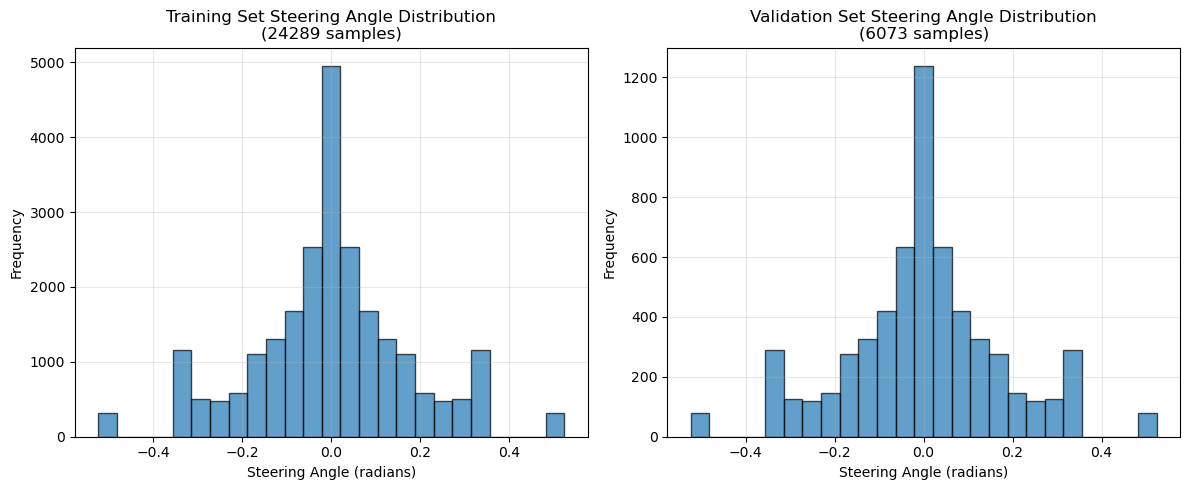


Training Set Steering Angle Statistics:
count    24289.000000
mean        -0.000049
std          0.173750
min         -0.523600
25%         -0.090600
50%          0.000000
75%          0.090600
max          0.523600
Name: steering_angle, dtype: float64

Validation Set Steering Angle Statistics:
count    6073.000000
mean        0.000195
std         0.173624
min        -0.523600
25%        -0.091100
50%         0.000000
75%         0.090600
max         0.523600
Name: steering_angle, dtype: float64


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Define paths
input_csv = 'labels_augmented.csv'  # Path to augmented dataset
train_csv = 'train_labels.csv'      # Output path for training set
val_csv = 'val_labels.csv'          # Output path for validation set

# Load the augmented dataset
data = pd.read_csv(input_csv)
data['steering_angle'] = pd.to_numeric(data['steering_angle'], errors='coerce')
data = data.dropna(subset=['steering_angle']).astype({'steering_angle': float})

# Discretize steering angles for stratification
num_bins = 25
data['angle_bin'] = pd.cut(data['steering_angle'], bins=num_bins, labels=False)

# Split the dataset (80% train, 20% validation)
train_data, val_data = train_test_split(
    data,
    test_size=0.2,  # 20% for validation
    random_state=42,  # For reproducibility
    stratify=data['angle_bin']  # Stratify by discretized steering angles
)

# Drop the temporary angle_bin column
train_data = train_data.drop(columns=['angle_bin'])
val_data = val_data.drop(columns=['angle_bin'])

# Save the splits
train_data.to_csv(train_csv, index=False)
val_data.to_csv(val_csv, index=False)
print(f"Training set saved to {train_csv} ({len(train_data)} samples)")
print(f"Validation set saved to {val_csv} ({len(val_data)} samples)")

# Visualize the distributions
plt.figure(figsize=(12, 5))

# Training set histogram
hist_train, bins = np.histogram(train_data['steering_angle'], bins=num_bins)
center = (bins[:-1] + bins[1:]) * 0.5
plt.subplot(1, 2, 1)
plt.bar(center, hist_train, width=(bins[1] - bins[0]), edgecolor='black', alpha=0.7)
plt.xlabel('Steering Angle (radians)')
plt.ylabel('Frequency')
plt.title(f'Training Set Steering Angle Distribution\n({len(train_data)} samples)')
plt.grid(True, alpha=0.3)

# Validation set histogram
hist_val, bins = np.histogram(val_data['steering_angle'], bins=num_bins)
plt.subplot(1, 2, 2)
plt.bar(center, hist_val, width=(bins[1] - bins[0]), edgecolor='black', alpha=0.7)
plt.xlabel('Steering Angle (radians)')
plt.ylabel('Frequency')
plt.title(f'Validation Set Steering Angle Distribution\n({len(val_data)} samples)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\nTraining Set Steering Angle Statistics:")
print(train_data['steering_angle'].describe())
print("\nValidation Set Steering Angle Statistics:")
print(val_data['steering_angle'].describe())

In [22]:
train_df = pd.read_csv('/home/memad/Desktop/f1/train_labels.csv')
val_df = pd.read_csv('/home/memad/Desktop/f1/val_labels.csv')

# Combine full paths
image_dir = '/home/memad/Desktop/f1/images_mirrored'
train_df['filepath'] = train_df['filename'].apply(lambda x: os.path.join(image_dir, x))
val_df['filepath'] = val_df['filename'].apply(lambda x: os.path.join(image_dir, x))


In [23]:
import random
from tensorflow.keras.utils import Sequence

def augment_image(img, steering_angle):
    # Random horizontal flip
    if random.random() < 0.5:
        img = cv2.flip(img, 1)
        steering_angle = -steering_angle

    # Random pan (translation)
    if random.random() < 0.5:
        tx = 100 * (np.random.rand() - 0.5)  # horizontal shift
        ty = 10 * (np.random.rand() - 0.5)   # vertical shift
        steering_angle += tx * 0.002  # Adjust steering angle
        trans_mat = np.float32([[1, 0, tx], [0, 1, ty]])
        img = cv2.warpAffine(img, trans_mat, (img.shape[1], img.shape[0]))

    # Random zoom
    if random.random() < 0.5:
        zoom_factor = 1 + (random.uniform(-0.2, 0.2))  # ±20%
        h, w = img.shape[:2]
        new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)
        resized = cv2.resize(img, (new_w, new_h))

        # Crop or pad to original size
        if zoom_factor < 1.0:
            # Padding
            pad_h = (h - new_h) // 2
            pad_w = (w - new_w) // 2
            img = cv2.copyMakeBorder(resized, pad_h, h - new_h - pad_h,
                                     pad_w, w - new_w - pad_w,
                                     borderType=cv2.BORDER_REPLICATE)
        else:
            # Cropping
            start_h = (new_h - h) // 2
            start_w = (new_w - w) // 2
            img = resized[start_h:start_h + h, start_w:start_w + w]

    # Random brightness
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    hsv = np.array(hsv, dtype=np.float64)
    hsv[:, :, 2] *= 0.25 + np.random.uniform()
    hsv[:, :, 2][hsv[:, :, 2] > 255] = 255
    hsv = np.array(hsv, dtype=np.uint8)
    img = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

    return img, steering_angle


class DataGenerator(Sequence):
    def __init__(self, df, batch_size=32, is_training=True):
        self.df = df
        self.batch_size = batch_size
        self.is_training = is_training

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, idx):
        batch_df = self.df.iloc[idx*self.batch_size:(idx+1)*self.batch_size]
        images = []
        angles = []

        for _, row in batch_df.iterrows():
            img = cv2.imread(row['filepath'])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (200, 66))  # NVIDIA model input

            angle = row['steering_angle']

            if self.is_training:
                img, angle = augment_image(img, angle)

            images.append(img)
            angles.append(angle)

        return np.array(images), np.array(angles)


In [24]:
train_gen = DataGenerator(train_df, batch_size=64, is_training=True)
val_gen = DataGenerator(val_df, batch_size=64, is_training=False)


In [33]:
def nvidia_model():
    model = Sequential()
    model.add(Lambda(lambda x: x/127.5 - 1.0, input_shape=(66, 200, 3)))
    model.add(Conv2D(24, (5, 5), strides=(2, 2), activation='relu'))
    model.add(Conv2D(36, (5, 5), strides=(2, 2), activation='relu'))
    model.add(Conv2D(48, (5, 5), strides=(2, 2), activation='relu'))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(Flatten())
    model.add(Dense(100, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(50, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='relu'))
    model.add(Dense(1))
    return model

model = nvidia_model()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='mse')


In [34]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 48s 123ms/step - loss: 0.0323 - val_loss: 0.0200
Epoch 2/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 45s 118ms/step - loss: 0.0238 - val_loss: 0.0088
Epoch 3/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 45s 118ms/step - loss: 0.0177 - val_loss: 0.0059
Epoch 4/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 45s 118ms/step - loss: 0.0138 - val_loss: 0.0040
Epoch 5/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 45s 118ms/step - loss: 0.0116 - val_loss: 0.0035
Epoch 6/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 45s 118ms/step - loss: 0.0107 - val_loss: 0.0039
Epoch 7/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 45s 118ms/step - loss: 0.0097 - val_loss: 0.0032
Epoch 8/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 45s 118ms/step - loss: 0.0084 - val_loss: 0.0023
Epoch 9/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 45s 118ms/step - loss: 0.0088 - val_loss: 0.0033
Epoch 10/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 45s 118ms/step - loss: 0.0075 - val_loss: 0.0021
Epoch 11/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 45s 118ms/step - loss: 0.0070 - val_loss: 0.0024
Epoch 12/30
380/380

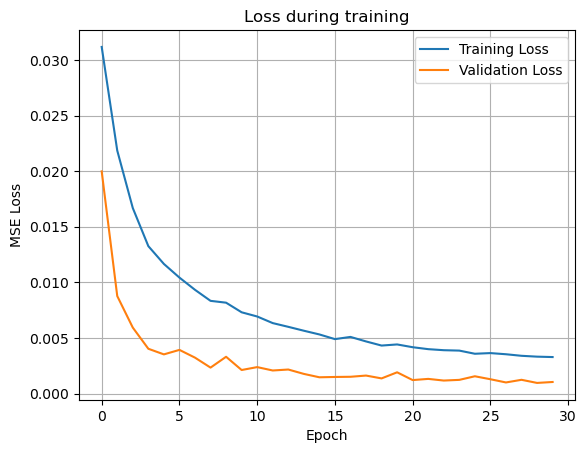

In [35]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss during training')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid()
plt.show()


In [36]:
model.save('steering_model.h5')